In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [4]:
# =============================================================
# LOAD DATA
# =============================================================
df_fights = pd.read_csv('/content/data.csv', encoding='latin1')
df_details = pd.read_csv('/content/raw_fighter_details.csv', encoding='latin1')

print("Data loaded successfully.")
print(f"Total number of fights: {len(df_fights)}")
print(f"Total number of fighters (in details table): {len(df_details)}")

# =============================================================
# DATA ENRICHMENT — ADDING EXPERIENCE LEVEL
# =============================================================

all_fighters = pd.concat([df_fights['R_fighter'], df_fights['B_fighter']])
experience_counts = all_fighters.value_counts().reset_index()
experience_counts.columns = ['fighter_name', 'total_fights']

# Fighters with more than 10 fights are labeled "Veteran", others are "Prospect"
experience_counts['Experience_Level'] = experience_counts['total_fights'].apply(
    lambda x: 'Veteran' if x > 10 else 'Prospect'
)

df_details = df_details.merge(experience_counts, on='fighter_name', how='left')
print("Enrichment complete: Experience levels have been added.")


# =============================================================
# DATA CLEANING FOR ANALYSIS
# =============================================================

df_clean = df_fights[['Winner', 'B_avg_TD_pct', 'B_avg_SIG_STR_pct']].dropna().copy()
df_clean['is_Blue_Winner'] = df_clean['Winner'].apply(lambda x: 1 if x == 'Blue' else 0)
print(f"\nUsable fights after cleaning: {len(df_clean)}")

# =============================================================
# SUMMARY STATISTICS (EDA)
# =============================================================

print("\nSummary Statistics")
print(df_clean.describe())


Data loaded successfully.
Total number of fights: 6012
Total number of fighters (in details table): 3596
Enrichment complete: Experience levels have been added.

Usable fights after cleaning: 4585

Summary Statistics
       B_avg_TD_pct  B_avg_SIG_STR_pct  is_Blue_Winner
count   4585.000000        4585.000000     4585.000000
mean       0.292650           0.453310        0.335224
std        0.273628           0.130458        0.472120
min        0.000000           0.000000        0.000000
25%        0.031250           0.376489        0.000000
50%        0.250000           0.450000        0.000000
75%        0.500000           0.527500        1.000000
max        1.000000           1.000000        1.000000


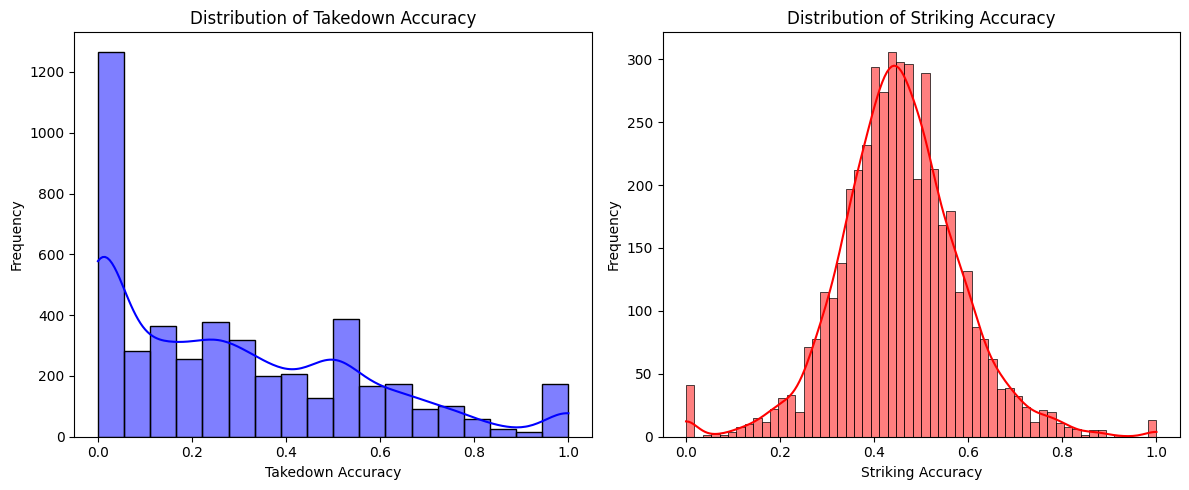

In [5]:
# =============================================================
# VISUALIZATION  — DISTRIBUTION PLOTS
# =============================================================

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df_clean['B_avg_TD_pct'], kde=True, color='blue')
plt.title('Distribution of Takedown Accuracy')
plt.xlabel('Takedown Accuracy')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.histplot(df_clean['B_avg_SIG_STR_pct'], kde=True, color='red')
plt.title('Distribution of Striking Accuracy')
plt.xlabel('Striking Accuracy')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

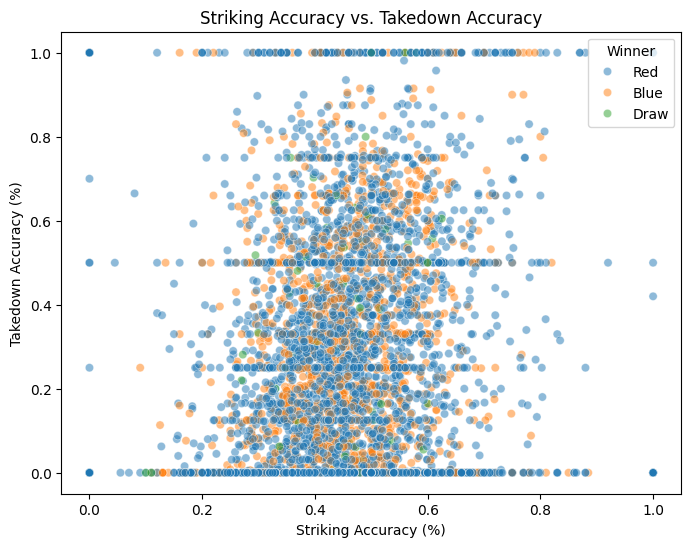

In [6]:
# =============================================================
# VISUALIZATION — SCATTER PLOT
# =============================================================

plt.figure(figsize=(8, 6))
sns.scatterplot(x='B_avg_SIG_STR_pct', y='B_avg_TD_pct', hue='Winner', data=df_clean, alpha=0.5)
plt.title('Striking Accuracy vs. Takedown Accuracy')
plt.xlabel('Striking Accuracy (%)')
plt.ylabel('Takedown Accuracy (%)')
plt.show()


/tmp/ipykernel_11739/4170146258.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Experience_Level', data=df_details, palette='viridis')


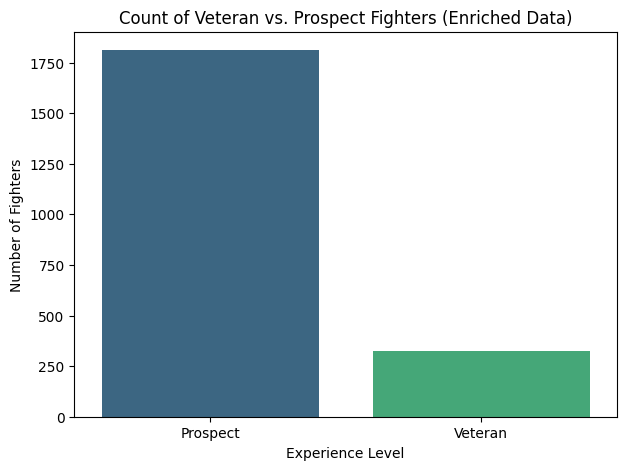

In [7]:
# =============================================================
# VISUALIZATION  — EXPERIENCE LEVEL COUNT
# =============================================================

plt.figure(figsize=(7, 5))
sns.countplot(x='Experience_Level', data=df_details, palette='viridis')
plt.title('Count of Veteran vs. Prospect Fighters (Enriched Data)')
plt.xlabel('Experience Level')
plt.ylabel('Number of Fighters')
plt.show()

/tmp/ipykernel_11739/2834184455.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Winner', y='B_avg_TD_pct', data=df_clean, palette='pastel')


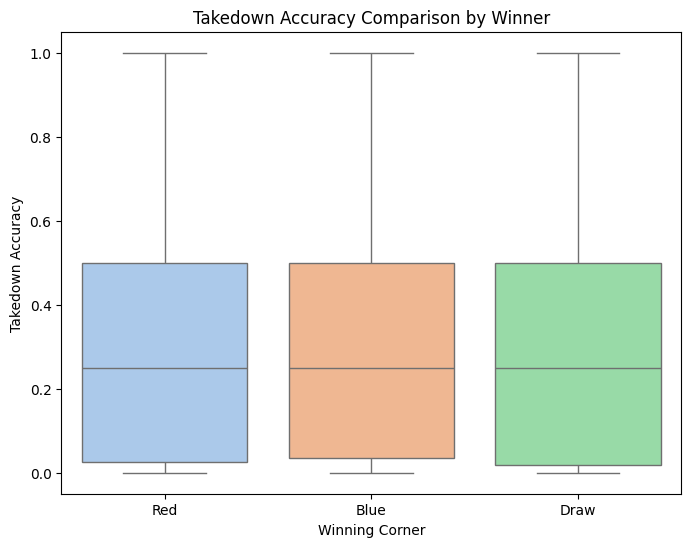

In [8]:
# =============================================================
# VISUALIZATION  — BOX PLOT
# =============================================================

plt.figure(figsize=(8, 6))
sns.boxplot(x='Winner', y='B_avg_TD_pct', data=df_clean, palette='pastel')
plt.title('Takedown Accuracy Comparison by Winner')
plt.xlabel('Winning Corner')
plt.ylabel('Takedown Accuracy')
plt.show()

In [9]:

# =============================================================
# HYPOTHESIS TESTING
# =============================================================

print("\nHypothesis Testing")

print("""
H0 (Null Hypothesis):  There is no significant difference in win rate between
                       fighters with high takedown accuracy and those with low takedown accuracy.
H1 (Alternative Hypothesis): Fighters with higher takedown accuracy have a significantly
                             higher win rate.
Significance level: α = 0.05
""")

threshold = df_clean['B_avg_TD_pct'].median()

high_grappling = df_clean[df_clean['B_avg_TD_pct'] >= threshold]['is_Blue_Winner']
low_grappling = df_clean[df_clean['B_avg_TD_pct'] < threshold]['is_Blue_Winner']

#T-TEST  :
t_stat, p_val = stats.ttest_ind(high_grappling, low_grappling)

print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_val:.4f}")

if p_val < 0.05:
    print("Result: Statistically significant difference found — H0 is rejected.")
    print("Conclusion: Fighters with higher takedown accuracy do win more often.")
else:
    print("Result: No significant difference found — Failed to reject H0.")
    print("Conclusion: Takedown accuracy alone does not appear to be a decisive factor in winning.")


df_details.to_csv('enriched_fighter_details.csv', index=False)
print("\nEnriched fighter data saved as 'enriched_fighter_details.csv'.")


Hypothesis Testing

H0 (Null Hypothesis):  There is no significant difference in win rate between
                       fighters with high takedown accuracy and those with low takedown accuracy.
H1 (Alternative Hypothesis): Fighters with higher takedown accuracy have a significantly
                             higher win rate.
Significance level: α = 0.05

T-Statistic: -0.4832
P-Value: 0.6289
Result: No significant difference found — Failed to reject H0.
Conclusion: Takedown accuracy alone does not appear to be a decisive factor in winning.

Enriched fighter data saved as 'enriched_fighter_details.csv'.
